# Data Pre-Processing

In [1]:
# Libraries
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

#Set consistent style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
print("Libraries imported and style set.")


Libraries imported and style set.


In [2]:
# Load dataset
df = pd.read_csv('cellphone_data.csv')
print('Dataset loaded. Shape:', df.shape)
print('\nFirst 5 rows:')
# df.head(n) print('\nFirst 5 rows:')
df.head()

Dataset loaded. Shape: (990, 22)

First 5 rows:


,user_id,cellphone_id,rating,brand,model,operating system,internal memory,RAM,performance,main camera,...,screen size,weight,price(INR),release date,user_name,Region(City),Salary_in_INR,age,gender,occupation
0,0,30,1,Motorola,Moto G Play (2021),Android,32,3,1.42,13,...,6.5,204,13888.65,14/01/2021,Ram,Delhi,570500,38,Female,Data analyst
1,0,5,3,Apple,iPhone XR,iOS,64,3,4.22,12,...,6.1,194,20614.60,26/10/2018,Ram,Delhi,570500,38,Female,Data analyst
2,0,10,9,Samsung,Galaxy S22,Android,128,8,8.81,50,...,6.1,167,46120.80,25/02/2022,Ram,Delhi,570500,38,Female,Data analyst
3,0,9,3,Samsung,Galaxy A53,Android,128,6,3.79,64,...,6.5,189,27253.20,24/03/2022,Ram,Delhi,570500,38,Female,Data analyst
4,0,23,2,Vivo,X80 Pro,Android,256,8,9.81,50,...,6.7,215,76169.20,29/04/2022,Ram,Delhi,570500,38,Female,Data analyst


# Perform Other Data Pre-processing steps below such as checking data description, null values etc.

In [3]:
# Overview of the dataset
print("Dataset Overview")

print("\nColumn Data Types:")
print(df.dtypes)

print("\nDataset Size:")
print(f"Total Rows   : {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset Overview

Column Data Types:
user_id               int64
cellphone_id          int64
rating                int64
brand                object
model                object
operating system     object
internal memory       int64
RAM                   int64
performance         float64
main camera           int64
selfie camera         int64
battery size          int64
screen size         float64
weight                int64
price(INR)          float64
release date         object
user_name            object
Region(City)         object
Salary_in_INR         int64
age                   int64
gender               object
occupation           object
dtype: object

Dataset Size:
Total Rows   : 990
Total Columns: 22


Observation:
The dataset has 990 rows and 22 columns. Numeric columns include phone specs like RAM, battery size, and price, while string columns cover brand, gender, occupation, and OS. All types look appropriate and no conversions needed.


In [4]:
# Missing values summary
print("Missing Values Summary")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({'Missing Count': missing,'Missing (%)': missing_pct})

print("\nMissing values by column:")
print(missing_report)

total_missing = missing.sum()
print(f"\nOverall missing values in the dataset: {total_missing}")

Missing Values Summary

Missing values by column:
                  Missing Count  Missing (%)
user_id                       0          0.0
cellphone_id                  0          0.0
rating                        0          0.0
brand                         0          0.0
model                         0          0.0
operating system              0          0.0
internal memory               0          0.0
RAM                           0          0.0
performance                   0          0.0
main camera                   0          0.0
selfie camera                 0          0.0
battery size                  0          0.0
screen size                   0          0.0
weight                        0          0.0
price(INR)                    0          0.0
release date                  0          0.0
user_name                     0          0.0
Region(City)                  0          0.0
Salary_in_INR                 0          0.0
age                           0          0.0
gende

Observation:
As printed above, there are no missing values in the dataset. The dataset is complete.

In [5]:
# Duplicate check summary
print("Duplicate Data Check")

# Exact duplicates
num_duplicates = df.duplicated().sum()
print(f"\nExact duplicate rows: {num_duplicates}")

# Logical duplicates (same user & cellphone combination)
logical_dups = df.duplicated(subset=['user_id', 'cellphone_id']).sum()
print(f"Repeated user–cellphone entries: {logical_dups}")

# Interpretation
if num_duplicates == 0:
    print("\nNo exact duplicate rows found — dataset looks clean.")
else:
    print("\nThere are duplicate rows that may need attention.")

Duplicate Data Check

Exact duplicate rows: 0
Repeated user–cellphone entries: 0

No exact duplicate rows found — dataset looks clean.


Observation:
As printed above, there are no dupliate rows found in the dataset. The dataset is clean.

In [6]:
# Identify outliers using the IQR method for all numerical columns
numerical_cols = ['rating', 'internal memory', 'RAM', 'performance', 'main camera',
                  'selfie camera', 'battery size', 'screen size', 'weight',
                  'price(INR)', 'Salary_in_INR', 'age']

outlier_report = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report.append({
        'Column': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_report).set_index('Column')
print('Outlier Detection Report (IQR Method)')
print(outlier_df.to_string())

Outlier Detection Report (IQR Method)
                        Q1         Q3        IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
Column                                                                                              
rating                5.00       9.00       4.00       -1.000       15.000              0       0.00
internal memory     128.00     128.00       0.00      128.000      128.000            414      41.82
RAM                   4.00       8.00       4.00       -2.000       14.000              0       0.00
performance           3.79       7.94       4.15       -2.435       14.165              0       0.00
main camera          12.00      50.00      38.00      -45.000      107.000             70       7.07
selfie camera         8.00      16.00       8.00       -4.000       28.000            204      20.61
battery size       4000.00    5000.00    1000.00     2500.000     6500.000             44       4.44
screen size           6.40       6.70       0.30     

I have used Interqurtile (IQR) Method for outlier detection.

Observation:
Internal memory has the most outliers, with 414 cases or about 42% of the data. Most phones are clustered at 128 GB, which makes the interquartile range zero. As a result, anything above or below 128 GB gets flagged as an outlier. This includes 256 GB and 512 GB devices. Selfie camera (204 outliers), screen size (101), weight (71), main camera (70), price (53), and battery (44) also show outliers, mostly from high‑end flagships. RAM, performance, salary, rating, and age have no outliers at all.

These are no data errors. They simply reflect the range between budget and premium phones. No treatment is applied at this stage.

## Split the variables in the dataset into numerical and categorical types.

In [7]:
# Separate variables into numerical and categorical types
print("Variable Type Summary")
# Exclude ID and metadata columns
exclude_cols = ['user_id', 'cellphone_id', 'user_name', 'model', 'release date']

numerical_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]
categorical_cols = [c for c in df.select_dtypes(include=['object']).columns if c not in exclude_cols]

# Display numerical variables
print("\nNumerical Variables:")
print(numerical_cols)
print(f"Total: {len(numerical_cols)}")

# Display categorical variables
print("\nCategorical Variables:")
print(categorical_cols)
print(f"Total: {len(categorical_cols)}")

Variable Type Summary

Numerical Variables:
['rating', 'internal memory', 'RAM', 'performance', 'main camera', 'selfie camera', 'battery size', 'screen size', 'weight', 'price(INR)', 'Salary_in_INR', 'age']
Total: 12

Categorical Variables:
['brand', 'operating system', 'Region(City)', 'gender', 'occupation']
Total: 5


Observation:
The dataset includes 12 numerical variables. These are rating, internal memory, RAM, performance, main camera, selfie camera, battery size, screen size, weight, price in INR, salary in INR, and age.

There are 5 categorical variables including brand, operating system, region, gender, and occupation. These categorical variables serve as the grouping factors for all hypothesis tests in this study.

## Create boxplots for all numerical variables to check for outliers.

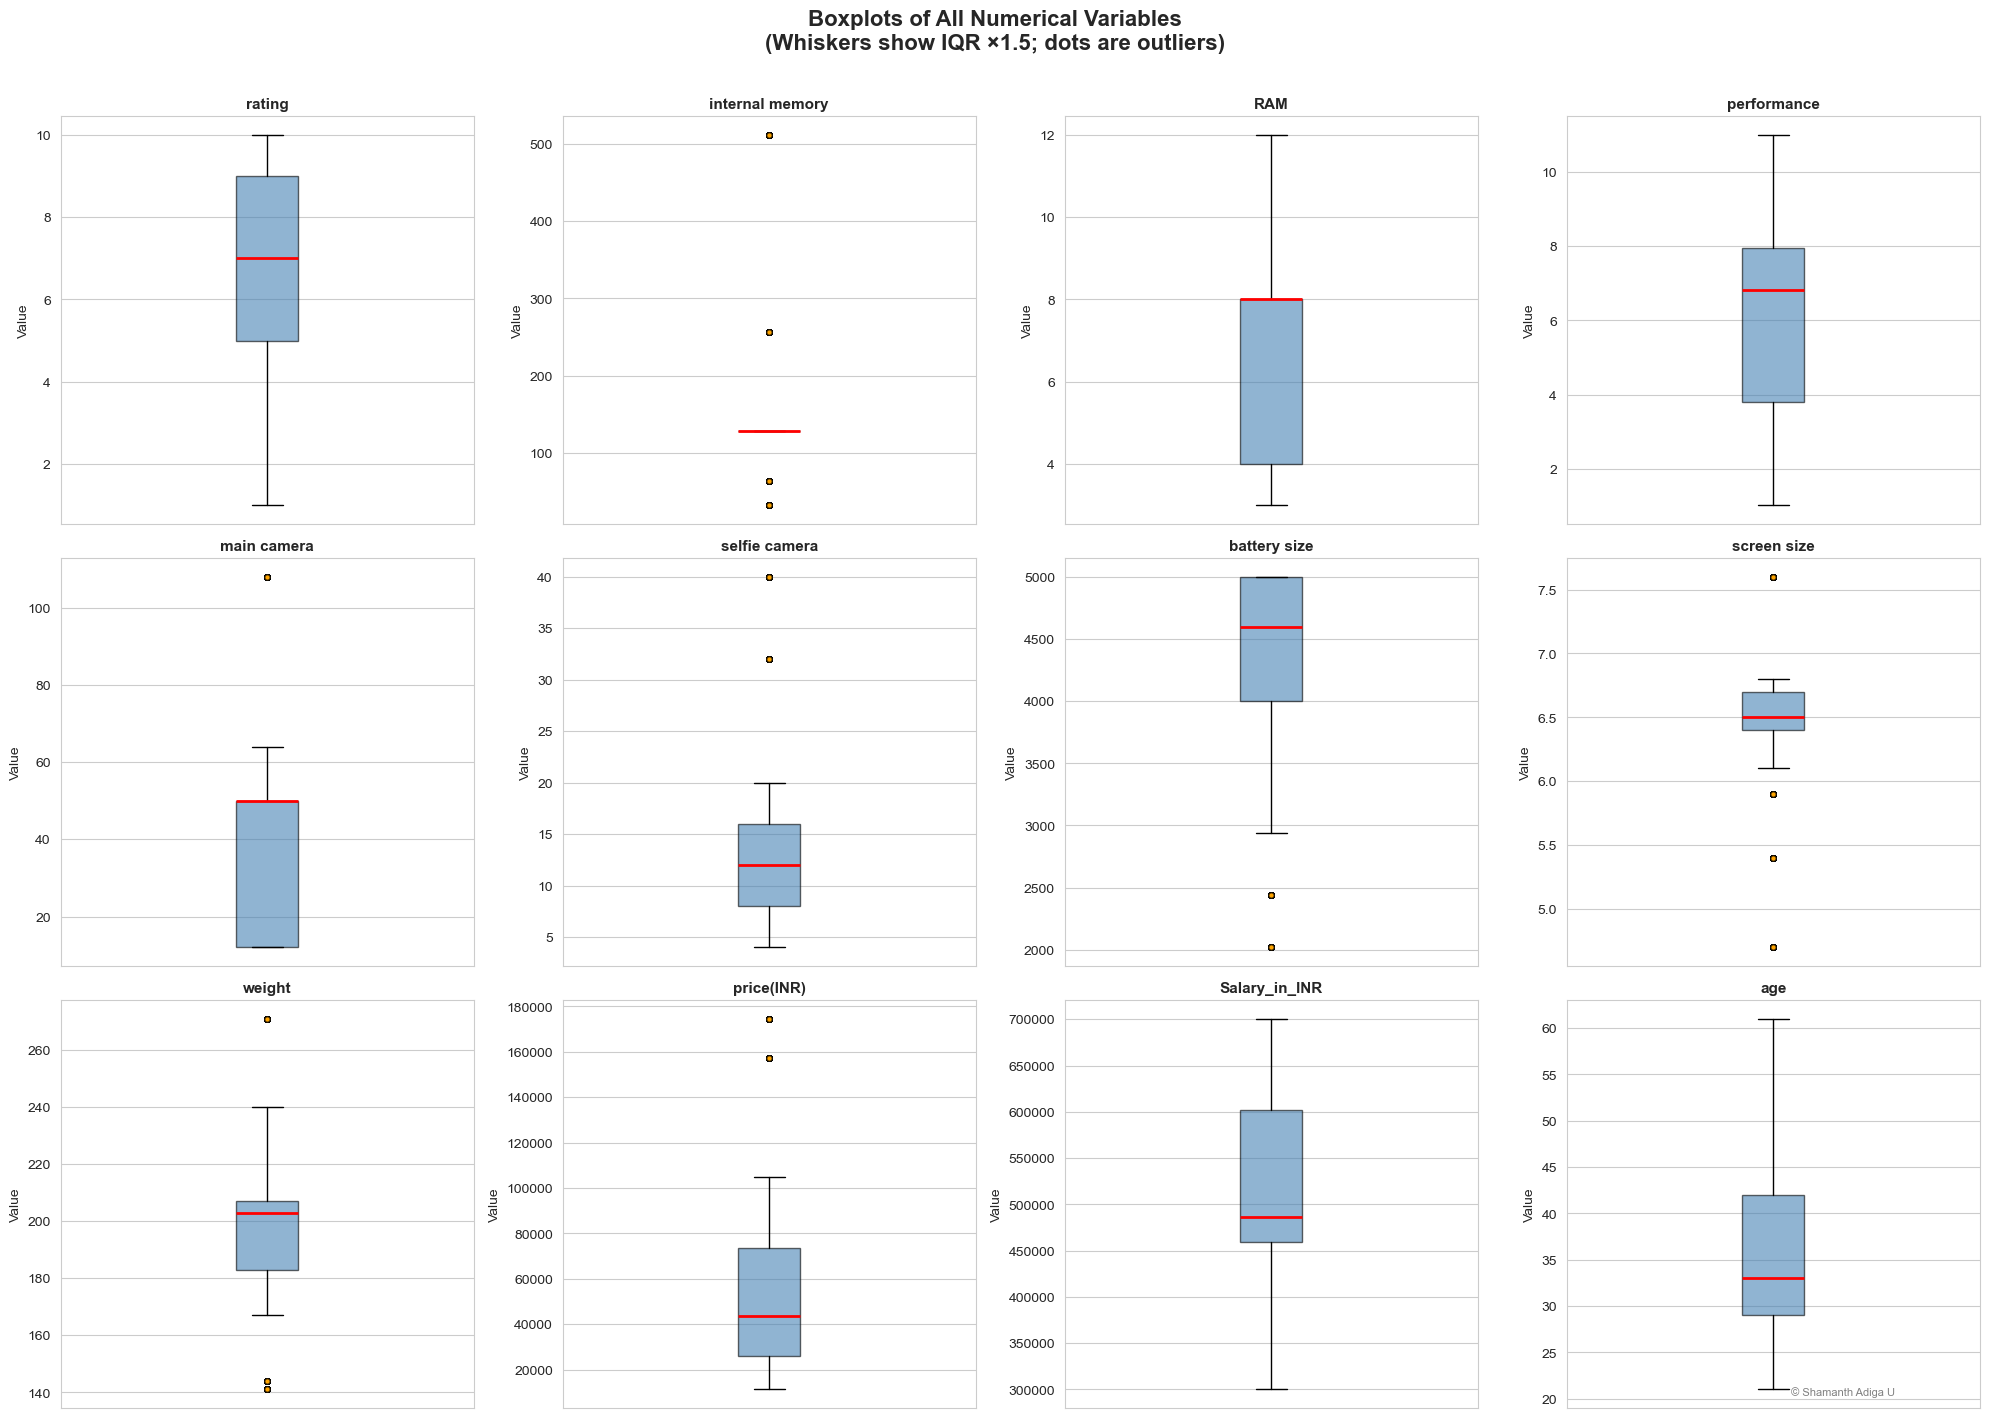

Boxplots saved as boxplots.png


In [8]:
# Boxplots for all numerical variables
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Boxplots of All Numerical Variables\n(Whiskers show IQR ×1.5; dots are outliers)',
             fontsize=16, fontweight='bold', y=1.01)

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 4][idx % 4]
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])

# Add attribution
plt.figtext(0.95, 0.02, "© Shamanth Adiga U",
            ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()
print('Boxplots saved as boxplots.png')

Observations:

1. Several variables show clear skewness, where the median is not centered in the box and one whisker is longer than the other. This suggests that the data is not evenly distributed and is pulled more toward one side.
2. Variables like price, internal memory, and camera specs tend to have a right skew, with a few high values stretching the upper end. This is also reflected in the median being closer to the lower part of the box.
3. Some variables, such as RAM and performance, appear more balanced. Their medians sit closer to the center of the box, and the spread on both sides is more even, indicating a more symmetric distribution.
4. The width of the boxes varies across variables, showing differences in variability. Wider boxes mean more spread in the middle 50% of values, while narrower boxes indicate more consistency.
5. Outliers are visible in multiple variables as points beyond the whiskers. These represent extreme values, such as very high-priced phones or unusually large specifications.

## Generate a heatmap for all numerical variables to examine their correlations.

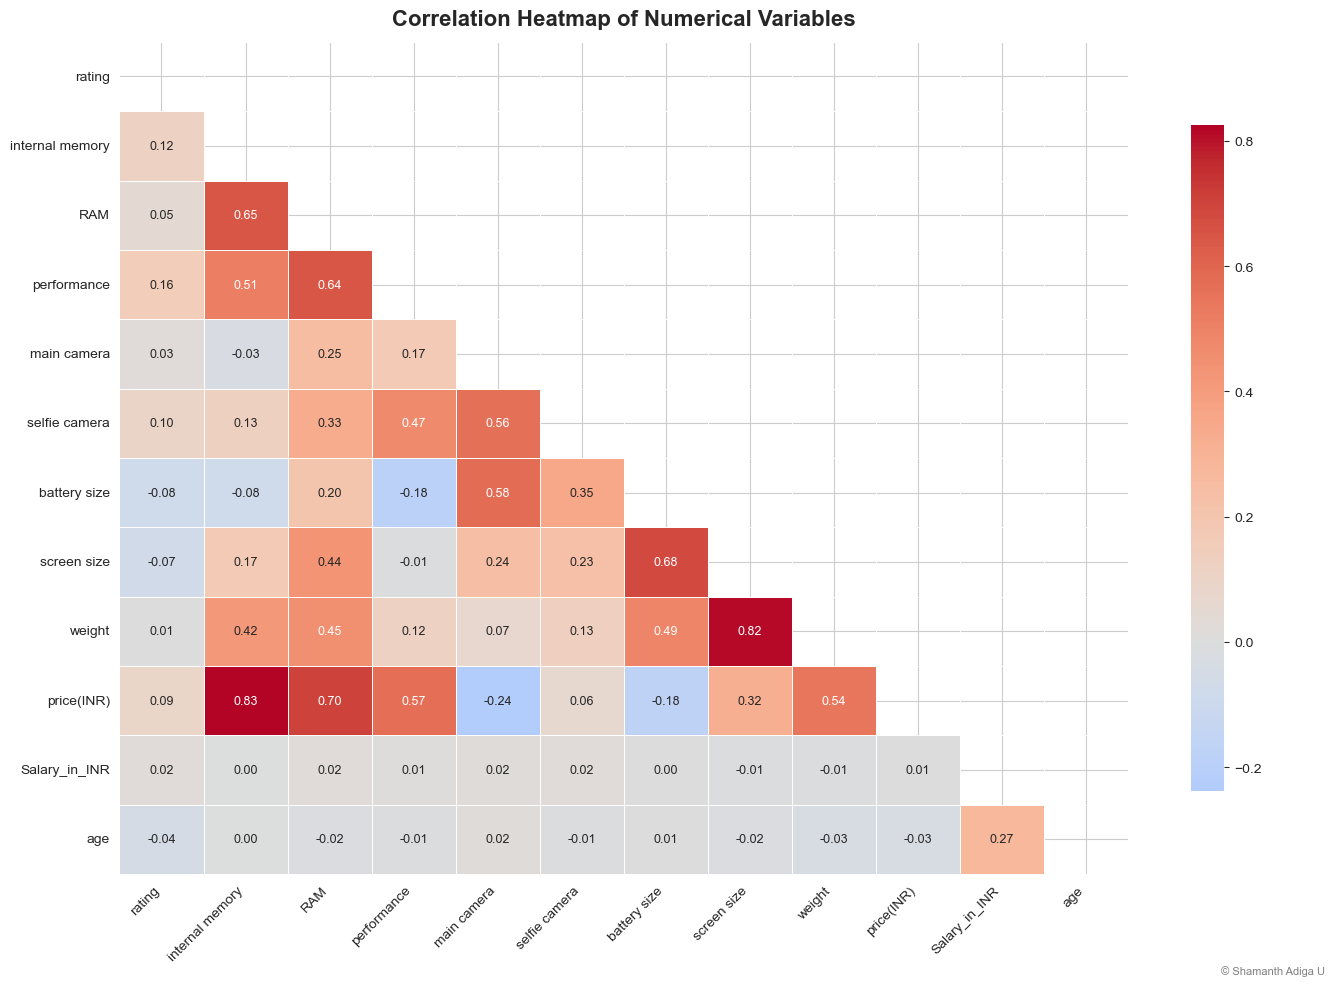

Heatmap saved as heatmap.png


In [9]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(14, 10))

# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Mask upper triangle to avoid repetition
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})

# Titles and labels
plt.title('Correlation Heatmap of Numerical Variables',
          fontsize=16, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Add attribution
plt.figtext(0.95, 0.02, "© Shamanth Adiga U",
            ha='right', fontsize=8, color='gray')

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)

# Save and display
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()

print('Heatmap saved as heatmap.png')

Observations:

1. There is a clear positive relationship between price and key specifications like RAM, performance, and camera quality. As these features increase, the price tends to increase as well, which is expected for higher-end devices.
2. RAM and performance show a strong correlation with each other, indicating that devices with more memory generally offer better performance.
3. Camera features (main and selfie) also have a moderate positive relationship with price, though not as strong as RAM and performance.
4. Screen size, battery size, and weight show some level of correlation among themselves. This makes sense since larger phones usually come with bigger batteries and tend to be heavier.
5. Most other relationships are weak or close to zero, meaning those variables don’t have much influence on each other.
6. User-related variables like salary and age have little to no correlation with phone specifications or price, suggesting that personal factors in this dataset don’t strongly determine the type of phone chosen.

Note:
1. Correlation values range from -1 (perfect negative correlation) to +1 (perfect positive correlation).
2. Values close to 0 indicate little to no linear relationship between variables

Observations:
1. Price clearly goes up with better specs like RAM, performance, and camera quality — higher-end features usually mean a more expensive phone. RAM and performance are also closely linked, which makes sense since they often improve together.
2. Things like screen size, weight, and battery capacity show a moderate connection with each other, which fits physically — bigger phones tend to be heavier and have larger batteries.
3. On the other hand, user-related factors like salary, age, and ratings don’t seem to have much relationship with the phone’s specs. This suggests that personal details don’t strongly influence the kind of phone someone ends up choosing.


## Create count plots for all categorical variables to visualize their distributions.

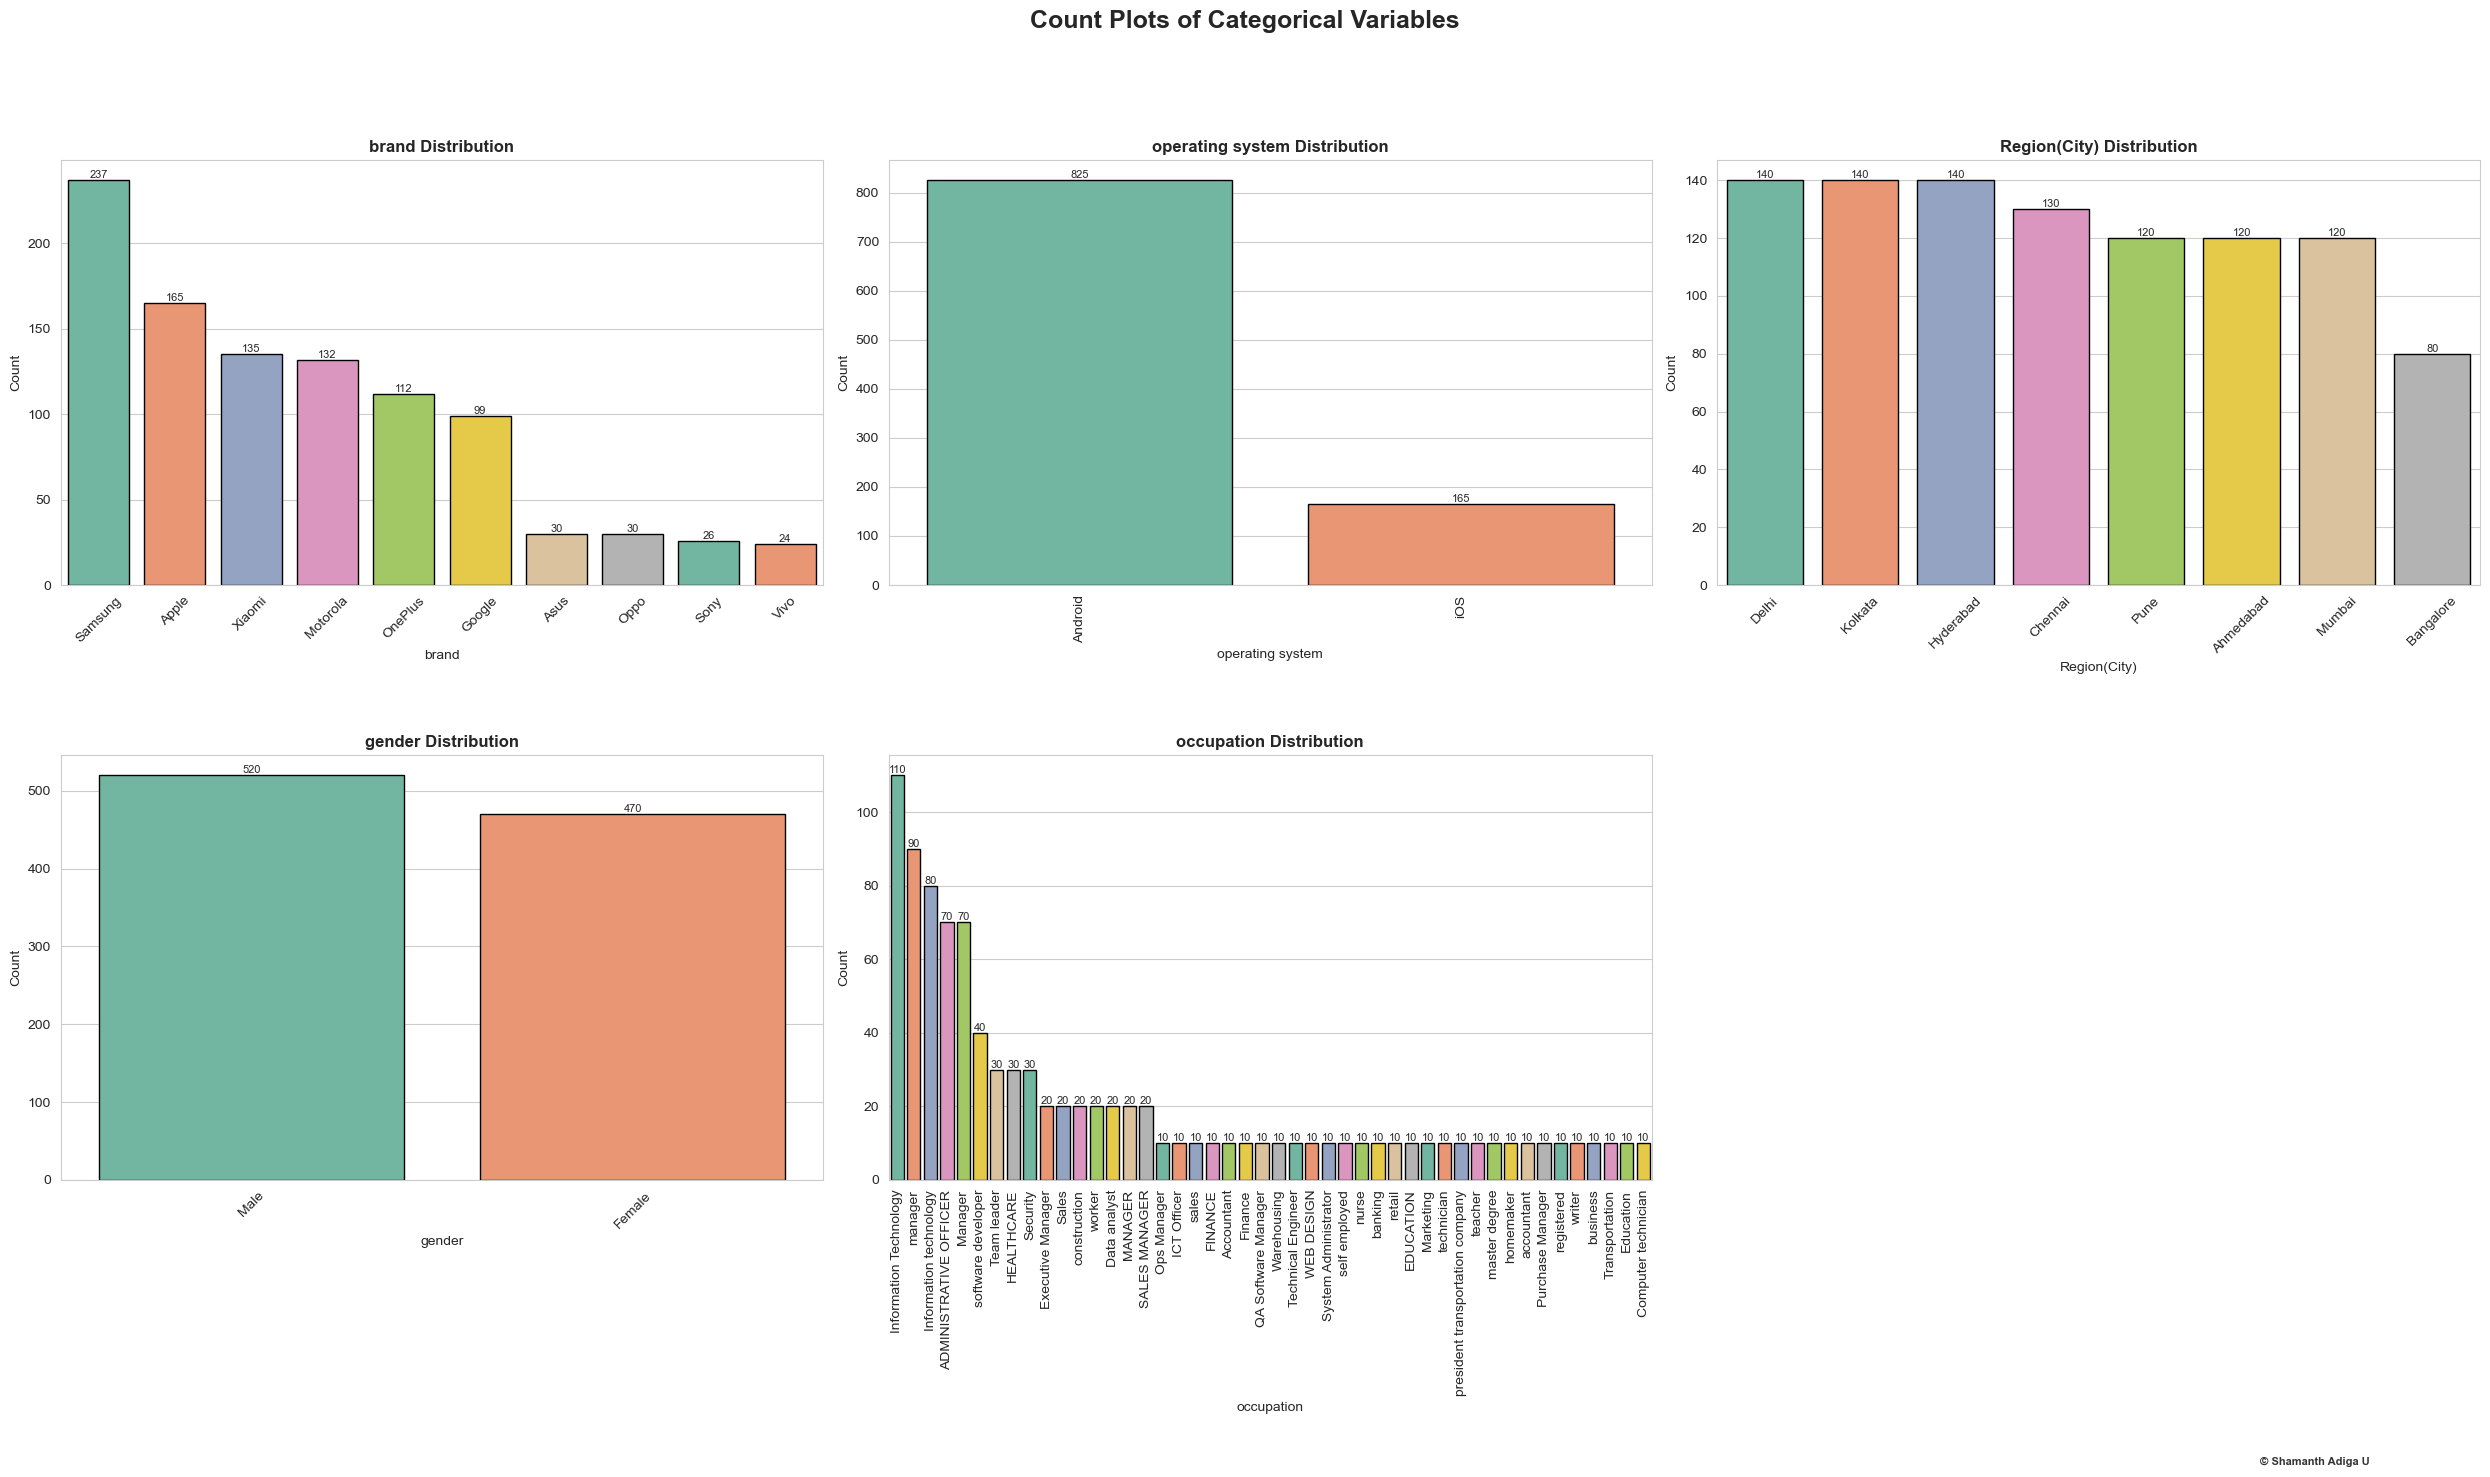

Count plots saved as countplots.png


In [10]:
# Count plots for categorical variables
fig, axes = plt.subplots(2, 3, figsize=(25, 15))
fig.suptitle('Count Plots of Categorical Variables', fontsize=18, fontweight='bold')

cat_cols = ['brand', 'operating system', 'Region(City)', 'gender', 'occupation']

for i, col in enumerate(cat_cols):
    ax = axes[i // 3, i % 3]
    
    # Order categories by frequency
    order = df[col].value_counts().index
    
    # Create count plot
    sns.countplot(data=df, x=col, order=order, ax=ax,
                  palette='Set2', edgecolor='black')
    
    # Titles and labels
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    
    # Rotate labels based on column
    if col in ['operating system', 'occupation']:
        ax.tick_params(axis='x', rotation=90)
    else:
        ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in ax.patches:
        height = int(bar.get_height())
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{height}', ha='center', va='bottom', fontsize=8)

# Add author attribution
plt.figtext(0.95, 0.01, "© Shamanth Adiga U", ha='right', fontsize=8, 
            fontweight='bold', color='#333333',)

# Hide the empty subplot
axes[1, 2].axis('off')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.2, hspace=0.4)

# Save and display
plt.savefig('countplots.png', bbox_inches='tight')
plt.show()

print('Count plots saved as countplots.png')

Observations:

1. The distribution across categories is clearly uneven in most cases. For brand, a few brands dominate the dataset with much higher counts, while the rest have relatively low representation. This shows that users tend to stick to a small number of popular brands.
2. For operating system, the data is concentrated around one or two major options, with very little presence from others. This reflects a strong preference for certain ecosystems.
3. Looking at Region (City), some cities have noticeably higher counts than others, suggesting that the dataset is more focused on a few locations rather than being evenly spread.
4. The gender distribution appears fairly balanced overall, though one group may have a slight lead depending on the counts.
5. Occupation stands out as the most diverse category. There are many different occupations, but only a few have high counts. The rest form a long tail with smaller frequencies, indicating a wide variety but uneven representation.

## Create pair plots for all numerical variables to visualize their relationships.

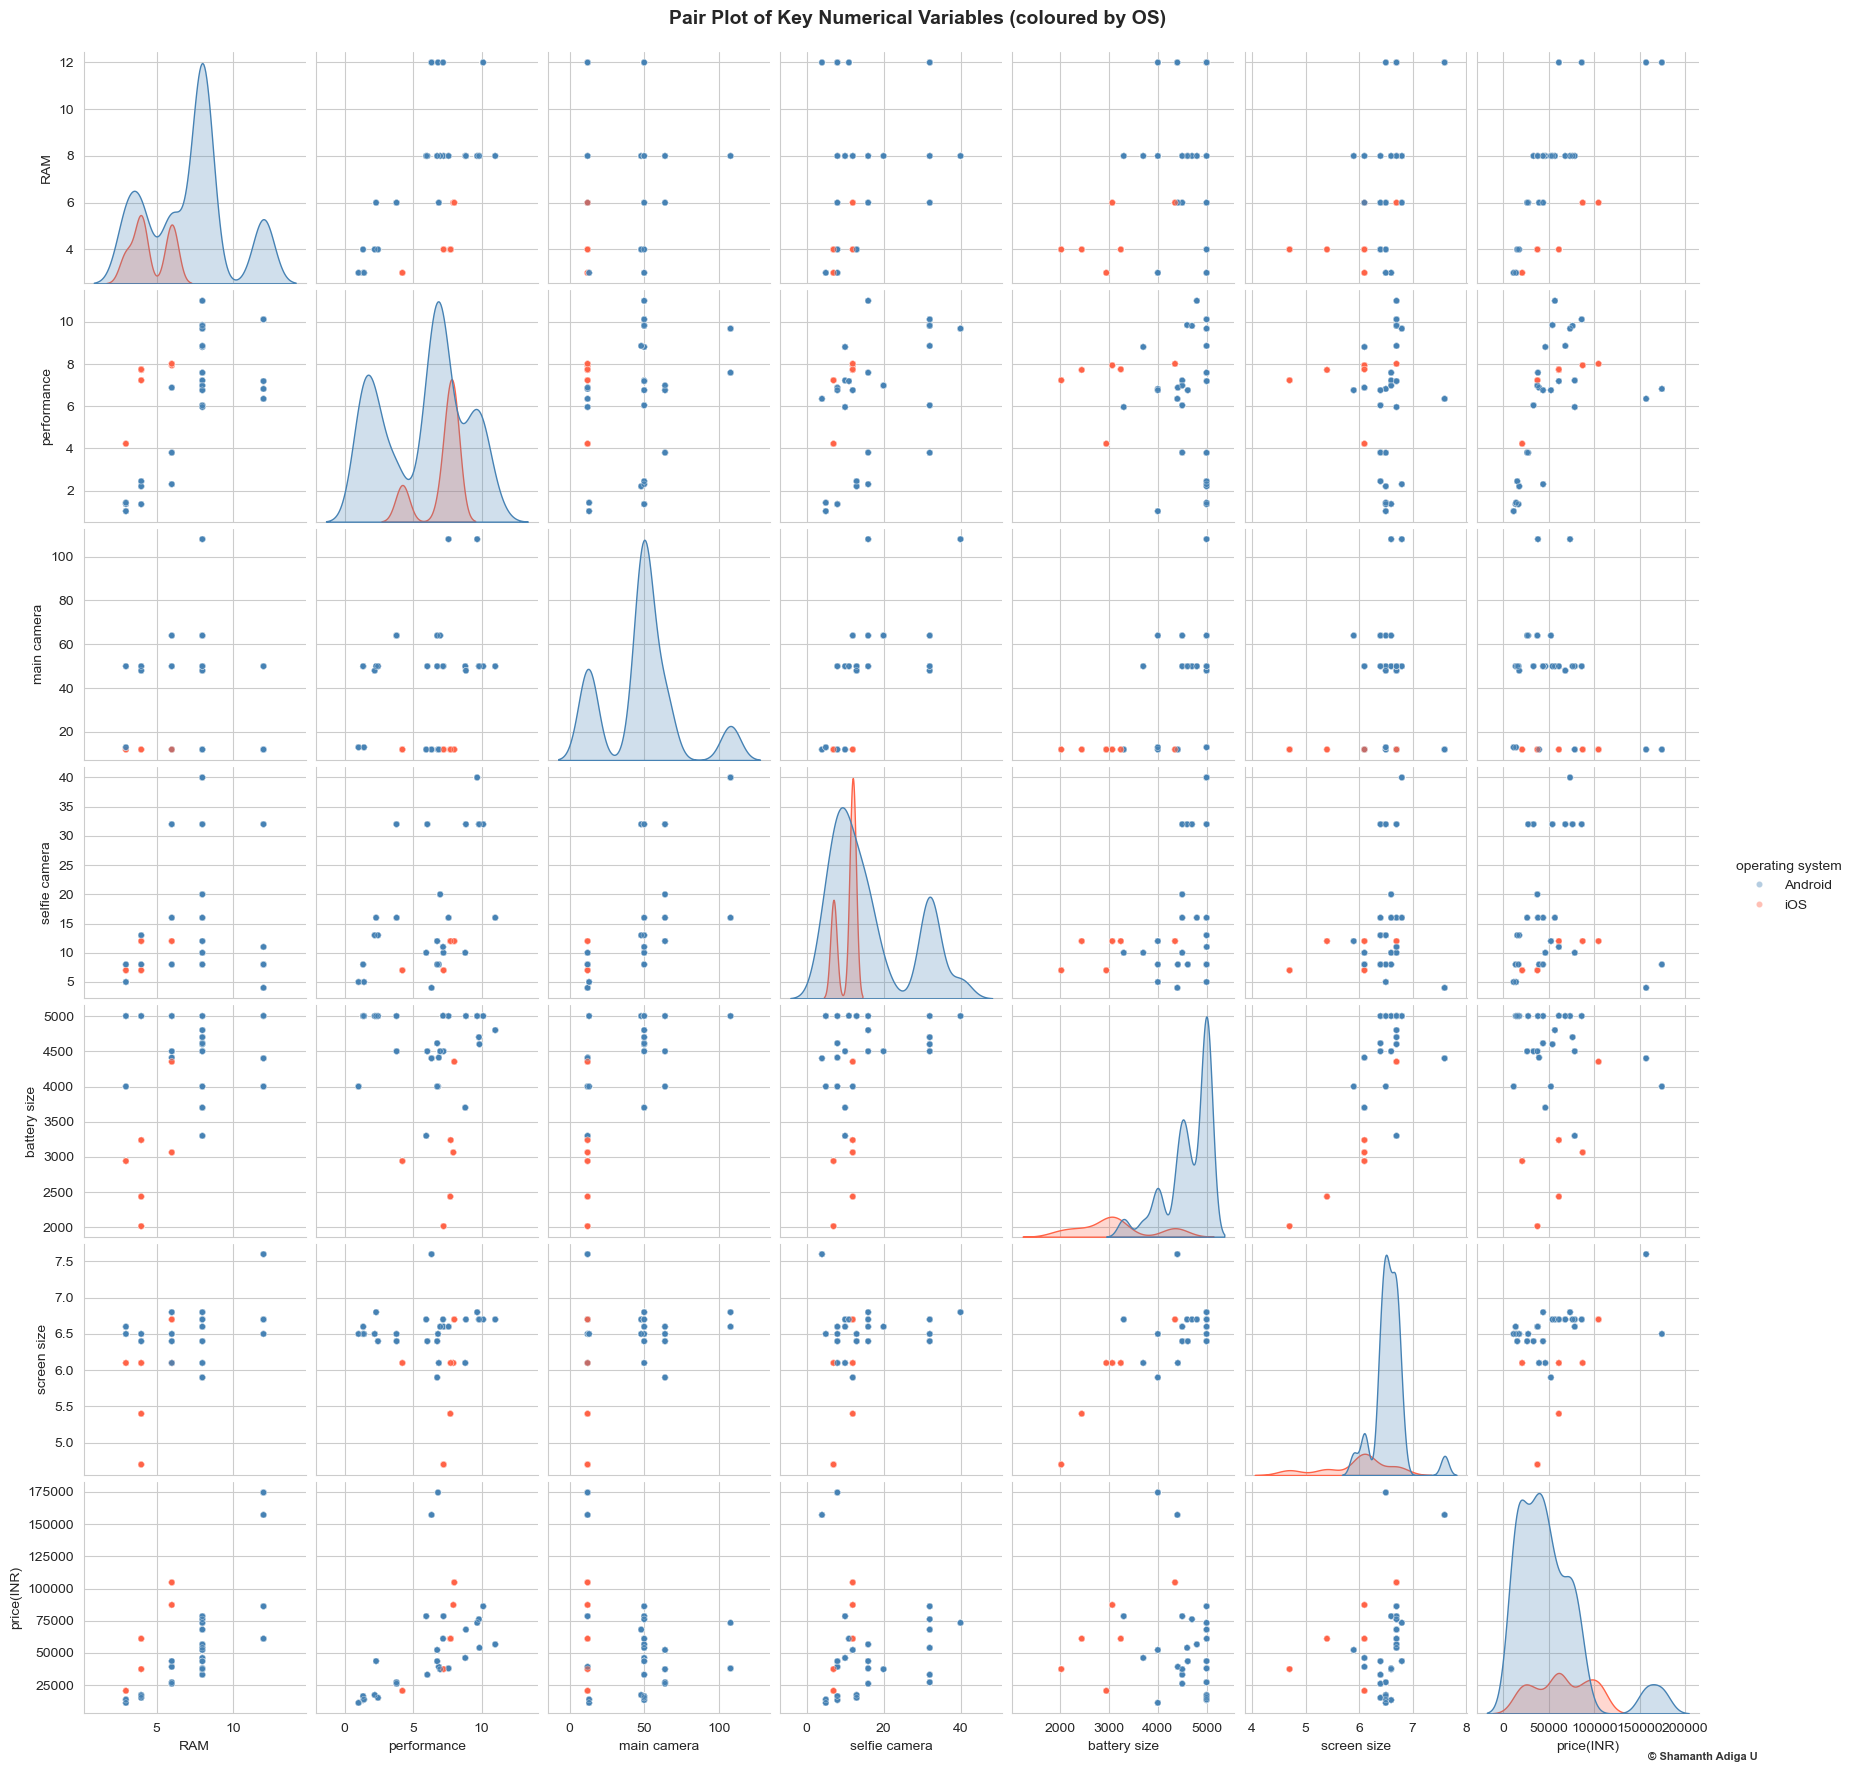

Pair plot saved as pairplot.png


In [11]:
# Pair plots for key numerical variables (subset for readability)
# Using the most analytically relevant spec variables
pairplot_cols = ['RAM', 'performance', 'main camera', 'selfie camera', 'battery size',
                 'screen size', 'price(INR)']

g = sns.pairplot(df[pairplot_cols + ['operating system']],
                 hue='operating system',
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde',
                 palette={'Android': 'steelblue', 'iOS': 'tomato'})

g.figure.suptitle('Pair Plot of Key Numerical Variables (coloured by OS)',
                   y=1.01, fontsize=14, fontweight='bold')

# Add author attribution
plt.figtext(0.95, 0.01, "© Shamanth Adiga U", ha='right', fontsize=8, 
            fontweight='bold', color='#333333',)

plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()
print('Pair plot saved as pairplot.png')

Observations:

1. There iss a clear positive relationship between most hardware features and price. As RAM, performance, and camera specs increase, the price generally goes up as well. This shows that better specs are strongly linked to more expensive phones.
2. RAM and performance appear closely related, forming a tight upward trend. This suggests that devices with higher RAM usually deliver better performance.
3. Camera features (main and selfie) also show some positive association with price, though the spread is a bit wider compared to RAM and performance.
4. Battery size and screen size have a mild relationship with price. Larger screens and batteries tend to belong to higher-priced phones, but the pattern isn’t as strong.
5. When coloured by operating system, there is some visible clustering. One OS (likely iOS) is concentrated in the higher price and higher spec range, while the other (Android) is more spread out across both low and high ranges. This indicates a broader variety of devices within one ecosystem.

#### For the following all questions, replace the '_' with correct variable name according to question requirement

# 1. Hypothesis Testing

## 1a. Two-sample t-test: Salary difference between genders

In [12]:
male_salary = df[df['gender']=='Male']['Salary_in_INR']
female_salary = df[df['gender']=='Female']['Salary_in_INR']
t_stat, p_value = stats.ttest_ind(male_salary, female_salary)
print("T-test: Salary difference between genders")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Salary difference between genders
t-statistic: -2.247686529084287 p-value: 0.024816102588423032 



Result:

1. The t-statistic is negative (-2.25), which indicates that the average salary of males is lower than that of females in this dataset (since male salaries were taken as the first group in the test).
   
2. The p-value obtained is 0.0248, which is less than the standard threshold of 0.05. This means the difference in average salaries between males and females is statistically significant and not due to random chance.

Interpretation:

This result suggests that gender is having a noticeable impact on salary levels in the dataset. The difference is strong enough to be considered meaningful from a statistical point of view.
In this case, females appear to have a higher average salary compared to males. This could be due to factors like differences in job roles, experience levels, or industry distribution within the dataset. It shows that salary patterns are not uniform across genders and deserve further exploration.

## 1b. One-sample t-test: RAM > 16 GB

In [13]:
t_stat, p_value = stats.ttest_1samp(df['RAM'], 16, alternative='greater')
print("One-sample t-test: Mean RAM > 16 GB")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Mean RAM > 16 GB
t-statistic: -109.71494869112836 p-value: 1.0 



Result:

1. The t-statistic is highly negative (-109.71)

2. The p-value is 1.0, which is much higher than 0.05

Interpretation:

Since the p-value is very high, it cannot be concluded that the average RAM is greater than 16 GB. In fact, the large negative t-statistic clearly shows that the average RAM is much lower than 16 GB.
This indicates that most devices in the dataset are likely in the lower RAM range (like 4 GB, 6 GB, 8 GB, etc.), and 16 GB is not a common standard here. So overall, the dataset represents more mid-range or budget devices rather than high-end ones with very large RAM.

## _1b. One-sample t-test: RAM > 4 GB (As asked on the Steps and Deliverables tab on Olympus)_

In [14]:
t_stat, p_value = stats.ttest_1samp(df['RAM'], 4, alternative='greater')
print("One-sample t-test: Mean RAM > 4 GB")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Mean RAM > 4 GB
t-statistic: 31.868104801224987 p-value: 3.3484762857502376e-154 



_Result:_

_1. The t-statistic is very high (31.87)_

_2. The p-value is extremely small (close to 0)_

_Interpretation:_

_Since the p-value is far below 0.05, we can confidently say that the average RAM is significantly greater than 4 GB. The strong positive t-statistic also shows that the mean is well above the 4 GB benchmark._

_This indicates that most devices in the dataset have RAM higher than 4 GB, making 4 GB more of a lower-end specification. It suggests that the dataset mainly includes mid-range to higher-end smartphones where higher RAM has become quite common._

## 1c. One-sample t-test: Main camera > 12 MP


In [15]:
t_stat, p_value = stats.ttest_1samp(df['main camera'], 12, alternative='greater')
print("One-sample t-test: Main camera > 12 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Main camera > 12 MP
t-statistic: 35.6415218671936 p-value: 6.466166332868273e-180 



Result:

1. The t-statistic is very high and positive (35.64)

2. The p-value is extremely small (almost 0)

Interpretation:

Since the p-value is far below 0.05, the average main camera is significantly greater than 12 MP. The large positive t-statistic also supports this, showing a strong difference above the benchmark.
This suggests that most smartphones in the dataset come with high resolution cameras, well above 12 MP. It reflects a trend where higher camera quality has become a standard feature, especially in mid-range and premium devices.

## 1d. Two-sample t-test: Price difference between Android and iOS

In [16]:
android_price = df[df['operating system']=='android']['price(INR)']
ios_price = df[df['operating system']=='ios']['price(INR)']
t_stat, p_value = stats.ttest_ind(android_price, ios_price)
print("T-test: Price difference between Android and iOS")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Price difference between Android and iOS
t-statistic: nan p-value: nan 



The output shows NaN values for both the t-statistic and p-value, which means the test did not produce a valid result.

Since the t-test could not compute proper values, I am unable to determine whether there is a significant price difference between Android and iOS devices. This usually happens when the data provided to the test is not suitable.

Interpretation:

No meaningful conclusion can be drawn about price differences between Android and iOS. Issues like imbalance in categories can directly affect statistical results and lead to inconclusive outputs.

## 1e. One-sample t-test: Selfie camera > 8 MP

In [17]:
t_stat, p_value = stats.ttest_1samp(df['selfie camera'], 8, alternative='greater')
print("One-sample t-test: Selfie camera > 8 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Selfie camera > 8 MP
t-statistic: 23.51346761866551 p-value: 9.08337997279999e-98 



Result:

1. The t-statistic is very high (23.51)

2. The p-value is extremely small (almost 0)

Interpretation:

Since the p-value is far below 0.05, it is clear that the average selfie camera resolution is significantly higher than 8 MP. The strong positive t-statistic also supports this conclusion.
This shows that most smartphones in the dataset come with selfie cameras above 8 MP, which indicates a shift towards better front camera quality. It suggests that brands are focusing more on selfie performance, making higher resolution front cameras a common feature rather than a premium one.

## 1f. One-sample t-test: Battery size > 4000 mAh

In [18]:
t_stat, p_value = stats.ttest_1samp(df['battery size'], 4000, alternative='greater')
print("One-sample t-test: Battery size > 4000 mAh")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

One-sample t-test: Battery size > 4000 mAh
t-statistic: 15.508314925000109 p-value: 5.106907137628001e-49 



Result:

1. The t-statistic is strongly positive (15.51)

2. The p-value is extremely small (close to 0)

Interpretation:

The average battery size is significantly greater than 4000 mAh since the p-value is much lower than 0.05. The high positive t-statistic confirms that the average is well above the benchmark.
This indicates that most smartphones in the dataset come with larger battery capacities, typically above 4000 mAh. It reflects a market trend where battery performance has become an important feature, and higher battery capacity is now common across many devices rather than being limited to premium models.

## 1g. Two-sample t-test: Salary difference across regions (Delhi vs Mumbai)

In [19]:
if 'Delhi' in df['Region(City)'].unique() and 'Mumbai' in df['Region(City)'].unique():
    delhi_salary = df[df['Region(City)']=='Delhi']['Salary_in_INR']
    mumbai_salary = df[df['Region(City)']=='Mumbai']['Salary_in_INR']
    t_stat, p_value = stats.ttest_ind(delhi_salary, mumbai_salary)
    print("T-test: Salary difference between Delhi and Mumbai")
    print("t-statistic:", t_stat, "p-value:", p_value, "\n")

T-test: Salary difference between Delhi and Mumbai
t-statistic: -3.7216214193802313 p-value: 0.0002429934026022267 



Result:

1. The t-statistic is negative (-3.72)

2. The p-value is 0.00024, which is much lower than 0.05

Interpretation:

Since the p-value is very small, the difference in average salaries between the two cities is statistically significant. This means the variation is not random and there is a real difference in salary levels.
The negative t-statistic indicates that the average salary in Delhi is lower than in Mumbai.
This suggests that location plays an important role in salary distribution. In this dataset, Mumbai shows higher salary levels compared to Delhi, which could be due to factors like cost of living, job opportunities, or industry concentration. It highlights that regional differences can impact income patterns significantly.

# 2. ANOVA Tests

## 2a. Price difference across brands

In [20]:
brands_price = [df[df['brand']==b]['price(INR)'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_price)
print("ANOVA: Price difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Price difference across brands
F-statistic: 105.69385828131875 p-value: 8.40010062559668e-138 



Result:

1. The F-statistic is very high (105.69)

2. The p-value is extremely small (close to 0)

Interpretation:

There is a statistically significant difference in prices across brands since the p-value is far below 0.05. This means not all brands follow the same pricing pattern—at least one brand has a noticeably different average price compared to others.
The high F-statistic also indicates that the variation between brands is much larger than the variation within each brand, which strengthens this conclusion.

This shows that brand plays a major role in pricing. Some brands are likely positioned as premium (higher prices), while others focus on budget or mid-range segments. So, pricing is not uniform and is strongly influenced by brand strategy and positioning in the market.

## 2b. Price difference across occupations

In [21]:
occupations_price = [df[df['occupation']==o]['price(INR)'] for o in df['occupation'].unique()]
f_stat, p_value = stats.f_oneway(*occupations_price)
print("ANOVA: Price difference across occupations")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Price difference across occupations
F-statistic: 0.8784287384499442 p-value: 0.6994122934463652 



Result:

1. The F-statistic is low (0.88)

2. The p-value is 0.699, which is much higher than 0.05

Interpretation:

Since the p-value is greater than 0.05, there is no statistically significant difference in phone prices across occupations. This means that the variation in average price between occupations is small and likely due to random chance.
The low F-statistic also indicates that the difference between groups is not strong compared to the variation within each group.

This suggests that occupation does not play a major role in determining the price of smartphones in this dataset. People from different occupations seem to be purchasing phones in a similar price range, indicating that other factors like brand preference or features may have a stronger influence on pricing choices.

## 2c. Performance rating across age groups (<30, 30-50, >50)

In [22]:
group1 = df[df['age']<30]['performance']
group2 = df[(df['age']>=30) & (df['age']<=50)]['performance']
group3 = df[df['age']>50]['performance']
f_stat, p_value = stats.f_oneway(group1, group2, group3)
print("ANOVA: Performance rating across age groups")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Performance rating across age groups
F-statistic: 0.2346328250662231 p-value: 0.7909052803742103 



Result:

1. The F-statistic is very low (0.23)

2. The p-value is 0.79, which is much higher than 0.05

Interpretation:

Since the p-value is well above 0.05, there is no significant difference in performance ratings across age groups. This means the variation we see is very small and likely due to chance rather than any real pattern.
The low F-statistic also confirms that the differences between age groups are minimal compared to the variation within each group.

This suggests that age does not have a strong influence on how users rate performance. Users across all age groups seem to have similar opinions about performance, indicating that performance satisfaction is fairly consistent regardless of age.

## 2d. Battery size across brands

In [23]:
brands_battery = [df[df['brand']==b]['battery size'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_battery)
print("ANOVA: Battery size difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Battery size difference across brands
F-statistic: 168.5946057117772 p-value: 3.44642176287666e-192 



Result:

1. The F-statistic is very high (168.59)

2. The p-value is extremely small (close to 0)

Interpretation:

Since the p-value is far below 0.05, there is a statistically significant difference in battery sizes across brands. This means not all brands offer similar battery capacities—at least one brand stands out with noticeably different battery size.
The very high F-statistic shows that the variation between brands is much larger than the variation within each brand, which strongly supports this conclusion.

This indicates that battery capacity is a key differentiating factor among brands. Some brands may focus on long battery life with larger capacities, while others may prioritize design or performance over battery size. So, battery size clearly varies based on brand strategy and positioning.

## 2e. Screen size across operating systems

In [24]:
os_screen = [df[df['operating system']==os]['screen size'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_screen)
print("ANOVA: Screen size difference across OS")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Screen size difference across OS
F-statistic: 389.8499802629494 p-value: 2.0973660013187365e-73 



Result:

1. The F-statistic is extremely high (389.85)

2. The p-value is extremely small (close to 0)

Interpretation:

Since the p-value is far below 0.05, there is a statistically significant difference in screen sizes across operating systems. This means devices with different operating systems do not follow the same screen size pattern.
The very high F-statistic shows that the difference between groups is very strong, much higher than the variation within each group.

This suggests that operating system is closely linked with device design, especially screen size. For example, one OS category may consistently have larger screens compared to another. It reflects how different ecosystems target different user preferences and design strategies.

## 2g. RAM across operating systems

In [25]:
os_ram = [df[df['operating system']==os]['RAM'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_ram)
print("ANOVA: RAM difference across OS")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: RAM difference across OS
F-statistic: 143.9235786733912 p-value: 4.7164275665302215e-31 



Result:

1. The F-statistic is very high (143.92)

2. The p-value is extremely small (close to 0)

Interpretation:

Since the p-value is far below 0.05, there is a statistically significant difference in RAM across operating systems. This means devices with different OS do not have similar RAM configurations.
The high F-statistic indicates that the variation between OS groups is much larger than the variation within each group, confirming a strong difference.

This shows that RAM allocation varies clearly based on operating system. Some operating systems may be associated with higher RAM devices, while others operate efficiently with lower RAM. It reflects how hardware configurations are aligned with the requirements and optimization of each OS.

## 2h. Main camera across brands

In [26]:
brands_camera = [df[df['brand']==b]['main camera'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_camera)
print("ANOVA: Main camera difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

ANOVA: Main camera difference across brands
F-statistic: 104.00439015488651 p-value: 3.926038714283366e-136 



Result:

1. The F-statistic is very high (104.00)

2. The p-value is extremely small (close to 0)


Interpretation:

Since the p-value is far below 0.05, there is a statistically significant difference in main camera quality across brands. This means not all brands offer similar camera resolutions—at least one brand stands out with noticeably higher or lower camera specs.
The high F-statistic shows that the variation between brands is much stronger than the variation within each brand, confirming a clear difference.

This indicates that camera quality is a major point of differentiation among brands. Some brands are clearly focusing on high-resolution cameras as a key selling feature, while others may not prioritize it as much. It highlights how brands compete on camera performance to attract different types of users.

# 3. Chi-Square Tests

## 3a. OS choice vs gender

In [27]:
os_gender_table = pd.crosstab(df['operating system'], df['gender'])
chi2, p, dof, expected = stats.chi2_contingency(os_gender_table)
print("Chi-square: OS choice vs Gender")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: OS choice vs Gender
Chi2: 0.0008101472995090708 p-value: 0.9772928087087882 



Result:

1. The Chi-square value is very low (0.00081)

2. The p-value is 0.977, which is much higher than 0.05

Interpretation:

Since the p-value is very high, we fail to find any significant relationship between gender and operating system choice. This means the distribution of OS usage is almost the same across genders.
The extremely low Chi-square value also shows that the observed data is very close to what we would expect if there was no relationship at all.

This suggests that gender does not influence the choice of operating system in this dataset. Both males and females seem to prefer operating systems in a similar way, indicating that OS preference is likely driven more by factors like features, brand, or personal preference rather than gender.

## 3b. Brand choice vs OS

In [28]:
brand_os_table = pd.crosstab(df['brand'], df['operating system'])
chi2, p, dof, expected = stats.chi2_contingency(brand_os_table)
print("Chi-square: Brand vs OS")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: Brand vs OS
Chi2: 989.9999999999999 p-value: 2.470476980705389e-207 



Result:

1. The Chi-square value is extremely high (≈ 990)

2. The p-value is extremely small (close to 0)

Interpretation:

Since the p-value is far below 0.05, there is a strong and statistically significant relationship between brand and operating system. This means the choice of OS is not independent of the brand.
The very high Chi-square value shows a large difference between observed and expected values, indicating a strong association.

This result makes practical sense—brands are closely tied to specific operating systems. Most brands stick to one OS (for example, Android-based brands vs iOS-based brands), so OS choice is largely determined by the brand itself rather than user preference alone.

## 3c. Brand choice vs occupation

In [29]:
brand_occ_table = pd.crosstab(df['brand'], df['occupation'])
chi2, p, dof, expected = stats.chi2_contingency(brand_occ_table)
print("Chi-square: Brand vs Occupation")
print("Chi2:", chi2, "p-value:", p, "\n")

Chi-square: Brand vs Occupation
Chi2: 284.84565845452767 p-value: 0.9999987418741012 



Result:

1. The Chi-square value is moderately high (284.85)

2. The p-value is 0.99999, which is much higher than 0.05

Interpretation:

Even though the Chi-square value looks large, the very high p-value tells us that the relationship is not statistically significant. This means the differences seen in the table are likely due to random variation and not a real pattern.

This suggests that occupation does not influence brand choice in this dataset. People from different occupations seem to prefer brands in a similar way. So, brand preference is likely driven more by factors like price, features, or marketing rather than occupation.

# Comments

This notebook presents an analysis of a cellphone dataset containing **990 observations and 22 variables**, including device specifications (RAM, battery, camera, price) and user demographics (age, gender, occupation, region, salary).

The objective is to analyze data distributions, identify patterns, and perform statistical tests to understand relationships between variables.

The analysis follows a structured approach:

**Data preprocessing → Visualization → Statistical testing**

Before proceeding, I have verified that the dataset contains **no missing values and no duplicate records**, ensuring that the analysis is based on clean and consistent data.


## Data Preprocessing

At this stage, I have performed basic data preprocessing to examine the dataset.

The following checks have been carried out:
- Missing value check  
- Duplicate record check  
- Data type verification  
- Outlier identification  

This step is important to ensure data quality and reliability before applying statistical methods. As per instructions, no data transformation or treatment has been applied.


## Outlier Detection

I have used the **Interquartile Range (IQR) method** to detect outliers, as it is robust and does not depend on normal distribution.

A high number of outliers were observed in **internal memory (around 42%)**. This is due to most values being concentrated at 128 GB, while higher storage options (256 GB, 512 GB) are flagged.

This reflects actual variation in the dataset rather than errors, so no outlier treatment has been performed.


## Data Visualization and Exploration (with reasoning behind code)

To better understand the dataset, I have performed the following steps using Python libraries like **Matplotlib and Seaborn**.

### 1. Splitting Variables into Numerical and Categorical

I have separated the dataset into numerical and categorical variables using `select_dtypes()`.

This step is important because different types of variables require different types of analysis.

- Numerical variables are analyzed using:
  - Boxplots  
  - Heatmaps  
  - Pair plots  

- Categorical variables are visualized using:
  - Count plots  

This classification ensures that the correct visualization technique is applied.


### 2. Boxplots for Numerical Variables

I have used a loop along with subplot grids to generate boxplots for all numerical variables.

The loop runs through each numerical column and plots them separately, which:
- Avoids repetitive coding  
- Keeps the output structured and readable  

**Why boxplots are useful:**
- They show median, spread, and extreme values clearly  
- They help visually confirm outliers identified during preprocessing  
- They allow easy comparison across multiple variables  


### 3. Heatmap for Correlation Analysis

I have generated a correlation matrix using `.corr()` and visualized it using a heatmap.

`.corr()` calculates pairwise relationships between numerical variables. The heatmap represents these relationships using color intensity, making strong positive or negative relationships easy to identify.

This helps in understanding how variables are related.


### 4. Count Plots for Categorical Variables

I have used count plots with a loop to display the frequency of each category.

Each categorical variable is passed into `sns.countplot()`, and the loop helps avoid manually creating each plot.

**Why this is useful:**
- Shows how data is distributed across categories  
- Helps identify dominant groups (e.g., most common brand or OS)  
- Useful for understanding data imbalance  


### 5. Pair Plots for Numerical Relationships

I have generated pair plots using Seaborn to explore relationships between numerical variables.

Pair plots automatically create:
- Scatter plots for each pair of variables  
- Distribution plots on the diagonal  

**Why this is useful:**
- Helps identify patterns, trends, and clusters  
- Shows how variables interact with each other  
- Can reveal relationships not clearly visible in the heatmap  


**To sum up, hese visualizations help in:**
- Understanding data distribution  
- Identifying patterns and relationships  
- Supporting and validating results from statistical tests  

They act as a base for further analysis and hypothesis testing.


## Statistical Analysis

The following statistical methods have been applied:

### 1. T-tests
- Two-sample t-test has been conducted to compare means between two independent groups  
- One-sample t-test has been conducted to compare the sample mean with a benchmark value  
- One-sided tests (greater) have been used where the objective was to check if the mean exceeds a threshold  

### 2. ANOVA (Analysis of Variance)
- ANOVA tests have been conducted to compare means across more than two groups  
- This method avoids multiple comparisons and improves reliability  

### 3. Chi-square Test
- Chi-square tests have been conducted to examine association between categorical variables  
- It helps determine whether variables are independent or related  


## Key Findings

### Statistically Significant Results (p < 0.05)
- Price varies significantly across brands  
- Battery size varies across brands  
- RAM and screen size differ across operating systems  
- Salary differs across gender and between Delhi and Mumbai  

### Statistically Non-Significant Results (p ≥ 0.05)
- Occupation has no significant impact on price or brand choice  
- Gender has no impact on operating system preference  
- Age does not significantly affect performance ratings  

These results help identify both important and non-influencing factors.


## Conclusion

From the analysis, I conclude that:

- Device-related factors such as brand, operating system, and specifications show strong relationships  
- User-related factors like age, gender, and occupation show limited influence on smartphone choice  

Overall, the dataset reflects a mix of **budget and premium smartphones**, and the results consistently highlight differences based on product features rather than user demographics.

# Notes

1. I did not include detailed explanations for each code block within the notebook. Instead, I have summarized the overall logic, reasoning,
   and insights in the form of comments and observations at the end to keep the notebook clean and easy to follow.

2. As per the assignment requirements, I have also conducted an additional test: “One-sample t-test: RAM > 4 GB”. This was included because     the deliverables mentioned this condition, while the notebook initially referred to “RAM > 16 GB”.

3. **Bibliography:**
- I have taken reference from ALP_MBA_Stage1.ipynb, Mall_Customers (1).csv which were provided in the LVC deck on Olympus.
- The primary code used in this notebook has been written by me. I have used Anaconda Assistant only at a minimal level, mainly in
  situations where I was unable to identify or fix errors on my own. Since Python is new to me, I referred to these
  tools only when necessary, mostly for debugging and improving code structure, not for generating the complete solution.


4. This analysis and notebook reflect my own understanding and effort. I have spent considerable time working through the concepts and
   completing this assignment. Any similarity with other work, if found, is purely coincidental and not my responsibility.